In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import display


# Detect the project root from the current directory or its parents
START_PATH = Path.cwd().resolve()
PROJECT_MARKERS = (
    "requirements.txt",
    "data",
    "notebooks",
    "reports",
)

PROJECT_ROOT = next(
    (
        candidate
        for candidate in (START_PATH, *START_PATH.parents)
        if all((candidate / marker).exists() for marker in PROJECT_MARKERS)
    ),
    None,
)

assert PROJECT_ROOT is not None, (
    "Project root could not be detected. "
    "Open the notebook from inside the nfl-pressure-prediction repository."
)

# Centralized input paths
ANALYTICAL_TABLE_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "pass_rush_analytical_table.parquet"
)
COLUMN_INVENTORY_PATH = (
    PROJECT_ROOT
    / "reports"
    / "analytical_table_column_inventory.csv"
)
QUALITY_REPORT_PATH = (
    PROJECT_ROOT
    / "reports"
    / "analytical_table_quality_report.csv"
)

INPUT_PATHS = {
    "analytical_table": ANALYTICAL_TABLE_PATH,
    "column_inventory": COLUMN_INVENTORY_PATH,
    "quality_report": QUALITY_REPORT_PATH,
}

input_check = pd.DataFrame(
    [
        {
            "artifact": artifact,
            "exists": path.is_file(),
            "path": str(path),
        }
        for artifact, path in INPUT_PATHS.items()
    ]
)

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
display(input_check)

assert input_check["exists"].all(), (
    "At least one required Stage 4 artifact is missing."
)

PROJECT_ROOT: C:\Users\yvett\OneDrive\Documentos\Francisco Fonseca\nfl-pressure-prediction


,artifact,exists,path
0,analytical_table,True,C:\Users\yvett\OneDrive\Documentos\Francisco F...
1,column_inventory,True,C:\Users\yvett\OneDrive\Documentos\Francisco F...
2,quality_report,True,C:\Users\yvett\OneDrive\Documentos\Francisco F...


In [3]:
# Load Stage 4 artifacts directly from disk
analytical_table = pd.read_parquet(ANALYTICAL_TABLE_PATH)
column_inventory = pd.read_csv(COLUMN_INVENTORY_PATH)
quality_report = pd.read_csv(QUALITY_REPORT_PATH)

loaded_artifacts = pd.DataFrame(
    [
        {
            "artifact": "analytical_table",
            "rows": analytical_table.shape[0],
            "columns": analytical_table.shape[1],
        },
        {
            "artifact": "column_inventory",
            "rows": column_inventory.shape[0],
            "columns": column_inventory.shape[1],
        },
        {
            "artifact": "quality_report",
            "rows": quality_report.shape[0],
            "columns": quality_report.shape[1],
        },
    ]
)

print(loaded_artifacts)

           artifact   rows  columns
0  analytical_table  36259       70
1  column_inventory     70        7
2    quality_report     12        4


In [5]:
# Define the binding column roles
IDENTIFIER_COLUMNS = [
    "gameId",
    "playId",
    "pass_rusher_nfl_id",
    "quarterback_nfl_id",
    "nearest_blocker_nfl_id",
]

SPLIT_COLUMNS = ["actual_week"]

AUDIT_COLUMNS = [
    "original_play_direction",
    "rusher_x",
    "rusher_y",
    "rusher_orientation",
    "rusher_direction",
    "quarterback_x",
    "quarterback_orientation",
    "quarterback_direction",
    "nearest_blocker_x",
    "nearest_blocker_y",
    "nearest_blocker_orientation",
    "nearest_blocker_direction",
]

TARGET_COLUMN = "pressure"
CATEGORICAL_FEATURES = ["rusher_position_lined_up"]

NON_PREDICTOR_COLUMNS = (
    IDENTIFIER_COLUMNS
    + SPLIT_COLUMNS
    + AUDIT_COLUMNS
    + [TARGET_COLUMN]
)

required_columns = NON_PREDICTOR_COLUMNS + CATEGORICAL_FEATURES

assert analytical_table.shape == (36_259, 70)
assert column_inventory.shape == (70, 7)
assert analytical_table.columns.is_unique
assert set(required_columns).issubset(analytical_table.columns)

# Recover numeric predictors while preserving table order
NUMERIC_FEATURES = [
    column
    for column in analytical_table.columns
    if column not in set(required_columns)
]

FEATURE_COLUMNS = NUMERIC_FEATURES + CATEGORICAL_FEATURES
ALL_ROLE_COLUMNS = NON_PREDICTOR_COLUMNS + FEATURE_COLUMNS

# Identify the inventory field containing analytical column names
inventory_name_fields = [
    column
    for column in column_inventory.columns
    if set(column_inventory[column].astype(str))
    == set(analytical_table.columns)
]

assert len(inventory_name_fields) == 1
INVENTORY_COLUMN_FIELD = inventory_name_fields[0]

# Validate the complete feature contract
assert len(NUMERIC_FEATURES) == 50
assert len(CATEGORICAL_FEATURES) == 1
assert len(FEATURE_COLUMNS) == 51
assert len(ALL_ROLE_COLUMNS) == len(set(ALL_ROLE_COLUMNS)) == 70
assert set(ALL_ROLE_COLUMNS) == set(analytical_table.columns)

assert all(
    pd.api.types.is_numeric_dtype(analytical_table[column])
    for column in NUMERIC_FEATURES
)
assert not pd.api.types.is_numeric_dtype(
    analytical_table[CATEGORICAL_FEATURES[0]]
)

contract_validation = pd.DataFrame(
    [
        {
            "check": "Analytical table shape",
            "expected": "36,259 × 70",
            "observed": (
                f"{analytical_table.shape[0]:,} × "
                f"{analytical_table.shape[1]}"
            ),
            "status": "PASS",
        },
        {
            "check": "Identifier metadata",
            "expected": 5,
            "observed": len(IDENTIFIER_COLUMNS),
            "status": "PASS",
        },
        {
            "check": "Split metadata",
            "expected": 1,
            "observed": len(SPLIT_COLUMNS),
            "status": "PASS",
        },
        {
            "check": "Audit-only columns",
            "expected": 12,
            "observed": len(AUDIT_COLUMNS),
            "status": "PASS",
        },
        {
            "check": "Numeric predictors",
            "expected": 50,
            "observed": len(NUMERIC_FEATURES),
            "status": "PASS",
        },
        {
            "check": "Categorical predictors",
            "expected": 1,
            "observed": len(CATEGORICAL_FEATURES),
            "status": "PASS",
        },
        {
            "check": "Columns assigned once",
            "expected": 70,
            "observed": len(set(ALL_ROLE_COLUMNS)),
            "status": "PASS",
        },
    ]
)

print(f"Inventory column field: {INVENTORY_COLUMN_FIELD}")
print(contract_validation)

Inventory column field: column
                    check     expected     observed status
0  Analytical table shape  36,259 × 70  36,259 × 70   PASS
1     Identifier metadata            5            5   PASS
2          Split metadata            1            1   PASS
3      Audit-only columns           12           12   PASS
4      Numeric predictors           50           50   PASS
5  Categorical predictors            1            1   PASS
6   Columns assigned once           70           70   PASS


In [7]:
# Reconstruct the approved temporal split
train_table = analytical_table.loc[
    analytical_table["actual_week"].between(1, 6)
].copy()

validation_table = analytical_table.loc[
    analytical_table["actual_week"].eq(7)
].copy()

test_table = analytical_table.loc[
    analytical_table["actual_week"].eq(8)
].copy()

split_tables = {
    "train": train_table,
    "validation": validation_table,
    "test": test_table,
}

expected_split_counts = {
    "train": {
        "weeks": {1, 2, 3, 4, 5, 6},
        "rows": 27_950,
        "plays": 6_587,
        "positives": 3_283,
    },
    "validation": {
        "weeks": {7},
        "rows": 3_865,
        "plays": 913,
        "positives": 427,
    },
    "test": {
        "weeks": {8},
        "rows": 4_444,
        "plays": 1_031,
        "positives": 504,
    },
}

split_summary_records = []

for split_name, split_table in split_tables.items():
    observed_weeks = set(split_table["actual_week"].unique())
    observed_plays = (
        split_table[["gameId", "playId"]]
        .drop_duplicates()
        .shape[0]
    )
    observed_positives = int(split_table[TARGET_COLUMN].sum())
    expected = expected_split_counts[split_name]

    assert observed_weeks == expected["weeks"]
    assert len(split_table) == expected["rows"]
    assert observed_plays == expected["plays"]
    assert observed_positives == expected["positives"]

    split_summary_records.append(
        {
            "split": split_name,
            "actual_week": (
                "1–6"
                if split_name == "train"
                else str(next(iter(observed_weeks)))
            ),
            "rows": len(split_table),
            "row_percentage": (
                f"{len(split_table) / len(analytical_table):.3%}"
            ),
            "plays": observed_plays,
            "positives": observed_positives,
            "prevalence": (
                f"{split_table[TARGET_COLUMN].mean():.3%}"
            ),
        }
    )

assert set(analytical_table["actual_week"].unique()) == set(range(1, 9))
assert sum(len(table) for table in split_tables.values()) == len(
    analytical_table
)

split_summary = pd.DataFrame(split_summary_records)
print(split_summary)

        split actual_week   rows row_percentage  plays  positives prevalence
0       train         1–6  27950        77.084%   6587       3283    11.746%
1  validation           7   3865        10.659%    913        427    11.048%
2        test           8   4444        12.256%   1031        504    11.341%


In [9]:
# Build unique play keys for each temporal split
play_keys_by_split = {
    split_name: set(
        split_table[["gameId", "playId"]]
        .drop_duplicates()
        .itertuples(index=False, name=None)
    )
    for split_name, split_table in split_tables.items()
}

split_pairs = [
    ("train", "validation"),
    ("train", "test"),
    ("validation", "test"),
]

overlap_records = []

for left_split, right_split in split_pairs:
    shared_plays = (
        play_keys_by_split[left_split]
        & play_keys_by_split[right_split]
    )

    overlap_records.append(
        {
            "split_comparison": f"{left_split} vs {right_split}",
            "shared_plays": len(shared_plays),
            "status": "PASS" if not shared_plays else "FAIL",
        }
    )

overlap_summary = pd.DataFrame(overlap_records)

all_play_keys = set().union(*play_keys_by_split.values())
split_play_count = sum(
    len(play_keys)
    for play_keys in play_keys_by_split.values()
)

assert overlap_summary["shared_plays"].eq(0).all()
assert len(all_play_keys) == 8_531
assert split_play_count == len(all_play_keys)

print(overlap_summary)

print(
    "Unique plays across all splits: "
    f"{len(all_play_keys):,}"
)

      split_comparison  shared_plays status
0  train vs validation             0   PASS
1        train vs test             0   PASS
2   validation vs test             0   PASS
Unique plays across all splits: 8,531


In [10]:
# Define every column forbidden from model inputs
FORBIDDEN_FEATURE_COLUMNS = set(NON_PREDICTOR_COLUMNS) | {
    "has_valid_manual_snap",
    "football_y",
    "football_y_norm",
    "pff_hit",
    "pff_hurry",
    "pff_sack",
    "pff_beatenByDefender",
    "pff_hitAllowed",
    "pff_hurryAllowed",
    "pff_sackAllowed",
    "pff_nflIdBlockedPlayer",
    "pff_blockType",
    "pff_backFieldBlock",
}

# Create development feature matrices and targets
X_train = train_table.loc[:, FEATURE_COLUMNS].copy()
y_train = (
    train_table.loc[:, TARGET_COLUMN]
    .astype("int8")
    .copy()
)

X_validation = validation_table.loc[:, FEATURE_COLUMNS].copy()
y_validation = (
    validation_table.loc[:, TARGET_COLUMN]
    .astype("int8")
    .copy()
)

# Validate shapes, alignment, target integrity, and leakage exclusion
assert X_train.shape == (27_950, 51)
assert X_validation.shape == (3_865, 51)
assert len(y_train) == 27_950
assert len(y_validation) == 3_865

assert X_train.index.equals(y_train.index)
assert X_validation.index.equals(y_validation.index)

assert X_train.columns.tolist() == FEATURE_COLUMNS
assert X_validation.columns.tolist() == FEATURE_COLUMNS

assert set(X_train.columns).isdisjoint(FORBIDDEN_FEATURE_COLUMNS)
assert set(X_validation.columns).isdisjoint(
    FORBIDDEN_FEATURE_COLUMNS
)

assert X_train.isna().sum().sum() == 0
assert X_validation.isna().sum().sum() == 0

assert set(y_train.unique()) == {0, 1}
assert set(y_validation.unique()) == {0, 1}
assert int(y_train.sum()) == 3_283
assert int(y_validation.sum()) == 427

modeling_matrices_summary = pd.DataFrame(
    [
        {
            "split": "train",
            "X_rows": X_train.shape[0],
            "X_columns": X_train.shape[1],
            "numeric_features": len(NUMERIC_FEATURES),
            "categorical_features": len(CATEGORICAL_FEATURES),
            "missing_values": int(X_train.isna().sum().sum()),
            "forbidden_features": len(
                set(X_train.columns) & FORBIDDEN_FEATURE_COLUMNS
            ),
            "positive_targets": int(y_train.sum()),
            "target_prevalence": f"{y_train.mean():.3%}",
        },
        {
            "split": "validation",
            "X_rows": X_validation.shape[0],
            "X_columns": X_validation.shape[1],
            "numeric_features": len(NUMERIC_FEATURES),
            "categorical_features": len(CATEGORICAL_FEATURES),
            "missing_values": int(
                X_validation.isna().sum().sum()
            ),
            "forbidden_features": len(
                set(X_validation.columns)
                & FORBIDDEN_FEATURE_COLUMNS
            ),
            "positive_targets": int(y_validation.sum()),
            "target_prevalence": f"{y_validation.mean():.3%}",
        },
    ]
)

print(modeling_matrices_summary)

        split  X_rows  X_columns  numeric_features  categorical_features  \
0       train   27950         51                50                     1   
1  validation    3865         51                50                     1   

   missing_values  forbidden_features  positive_targets target_prevalence  
0               0                   0              3283           11.746%  
1               0                   0               427           11.048%  


## Stage 6 metric policy

The modeling unit is one pass rusher in one play. Models will be fitted only
with weeks 1–6 and compared only on validation week 7.

### Primary metric

**Average Precision (AP)** is the primary model-comparison metric.

AP summarizes the precision-recall relationship across decision thresholds and
focuses evaluation on the positive class (`pressure = 1`). This is appropriate
because only 11.622% of the complete analytical sample is positive.

A constant-score classifier has an expected AP approximately equal to the
positive prevalence of the evaluated split. For validation, that reference is
approximately 11.048%. A useful model must improve on this trivial ranking
benchmark.

The metric will be reported specifically as **Average Precision**, not as a
generic or trapezoidal “PR-AUC”.

### Secondary metrics

| Metric | Direction | Purpose |
|---|---|---|
| Average Precision | Higher is better | Primary comparison under class imbalance |
| ROC-AUC | Higher is better | Secondary assessment of ranking across both classes |
| Log Loss | Lower is better | Quality and confidence of predicted probabilities |

ROC-AUC is secondary because it can appear favorable in imbalanced data even
when positive-class precision remains limited. Log Loss complements ranking
metrics by penalizing incorrect and overconfident probabilities.

### Metrics not used for model selection in Stage 6

Accuracy will not be used as the primary metric. Predicting `No pressure` for
every validation row would already produce approximately 88.952% accuracy while
detecting zero pressure cases.

Precision, recall, F1 and the confusion matrix depend on a classification
threshold. They will not be used to select a threshold during this stage. The
threshold will be selected later using validation only, after the model and
pipeline have been selected.

### Evaluation boundaries

- Preprocessing and model fitting use train only.
- Baseline comparisons use validation only.
- Test week 8 remains untouched.
- Test will not be used for preprocessing, model comparison, hyperparameter
  selection or threshold selection.

In [13]:
from sklearn.metrics import (
    average_precision_score,
    log_loss,
    roc_auc_score,
)


def evaluate_probabilities(
    y_true,
    positive_probability,
    model_name,
    split_name="validation",
):
    """
    Evaluate positive-class probabilities using the fixed Stage 6 metrics.

    Parameters
    ----------
    y_true : array-like
        Observed binary targets.
    positive_probability : array-like
        Predicted probabilities for pressure = 1.
    model_name : str
        Name used to identify the evaluated model.
    split_name : str, default="validation"
        Evaluated data split.

    Returns
    -------
    pandas.DataFrame
        One-row table containing Average Precision, ROC-AUC and Log Loss.
    """
    y_true_series = pd.Series(y_true).reset_index(drop=True)
    probability_series = pd.Series(
        positive_probability,
        dtype="float64",
    ).reset_index(drop=True)

    assert len(y_true_series) == len(probability_series)
    assert set(y_true_series.unique()).issubset({0, 1})
    assert probability_series.notna().all()
    assert probability_series.between(0.0, 1.0).all()

    return pd.DataFrame(
        [
            {
                "model": model_name,
                "split": split_name,
                "average_precision": average_precision_score(
                    y_true_series,
                    probability_series,
                ),
                "roc_auc": roc_auc_score(
                    y_true_series,
                    probability_series,
                ),
                "log_loss": log_loss(
                    y_true_series,
                    probability_series,
                    labels=[0, 1],
                ),
            }
        ]
    )


# Smoke test with a small artificial example
smoke_test_result = evaluate_probabilities(
    y_true=[0, 0, 1, 1],
    positive_probability=[0.10, 0.30, 0.70, 0.90],
    model_name="evaluation_function_smoke_test",
    split_name="synthetic",
)

assert smoke_test_result.loc[0, "average_precision"] == 1.0
assert smoke_test_result.loc[0, "roc_auc"] == 1.0
assert smoke_test_result.loc[0, "log_loss"] > 0.0

display(
    smoke_test_result.style.format(
        {
            "average_precision": "{:.6f}",
            "roc_auc": "{:.6f}",
            "log_loss": "{:.6f}",
        }
    )
)

,model,split,average_precision,roc_auc,log_loss
0,evaluation_function_smoke_test,synthetic,1.000000,1.000000,0.231018


In [14]:
from sklearn.dummy import DummyClassifier


# Fit a constant-probability baseline using train only
dummy_prior = DummyClassifier(
    strategy="prior",
    random_state=42,
)

dummy_prior.fit(X_train, y_train)

# Evaluate only on validation week 7
dummy_validation_probability = dummy_prior.predict_proba(
    X_validation
)[:, 1]

dummy_prior_results = evaluate_probabilities(
    y_true=y_validation,
    positive_probability=dummy_validation_probability,
    model_name="DummyClassifier_prior",
    split_name="validation",
)

# Validate baseline behavior
train_prevalence = float(y_train.mean())
validation_prevalence = float(y_validation.mean())

assert dummy_validation_probability.shape == (3_865,)
assert dummy_validation_probability.min() == train_prevalence
assert dummy_validation_probability.max() == train_prevalence

assert dummy_prior_results.loc[0, "average_precision"] == (
    validation_prevalence
)
assert dummy_prior_results.loc[0, "roc_auc"] == 0.5

dummy_baseline_summary = dummy_prior_results.assign(
    learned_probability=train_prevalence,
    validation_prevalence=validation_prevalence,
)

display(
    dummy_baseline_summary.style.format(
        {
            "average_precision": "{:.6f}",
            "roc_auc": "{:.6f}",
            "log_loss": "{:.6f}",
            "learned_probability": "{:.6f}",
            "validation_prevalence": "{:.6f}",
        }
    )
)

,model,split,average_precision,roc_auc,log_loss,learned_probability,validation_prevalence
0,DummyClassifier_prior,validation,0.110479,0.500000,0.347754,0.117460,0.110479


In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


# Define preprocessing by feature type
logistic_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            NUMERIC_FEATURES,
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
            CATEGORICAL_FEATURES,
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=True,
)

# Build the first interpretable modeling pipeline
logistic_baseline = Pipeline(
    steps=[
        ("preprocessor", logistic_preprocessor),
        (
            "classifier",
            LogisticRegression(
                C=1.0,
                class_weight=None,
                solver="lbfgs",
                max_iter=2_000,
                random_state=42,
            ),
        ),
    ]
)

# Fit preprocessing and model using train only
logistic_baseline.fit(X_train, y_train)

# Generate probabilities only for validation week 7
logistic_validation_probability = (
    logistic_baseline.predict_proba(X_validation)[:, 1]
)

logistic_baseline_results = evaluate_probabilities(
    y_true=y_validation,
    positive_probability=logistic_validation_probability,
    model_name="LogisticRegression_unweighted",
    split_name="validation",
)

# Compare against the trivial baseline
stage_6_results = pd.concat(
    [
        dummy_prior_results,
        logistic_baseline_results,
    ],
    ignore_index=True,
)

classifier = logistic_baseline.named_steps["classifier"]
transformed_feature_names = (
    logistic_baseline.named_steps["preprocessor"]
    .get_feature_names_out()
)

assert logistic_validation_probability.shape == (3_865,)
assert pd.Series(logistic_validation_probability).between(0, 1).all()
assert classifier.n_iter_[0] < classifier.max_iter
assert len(transformed_feature_names) == classifier.coef_.shape[1]

print(
    "Transformed features: "
    f"{len(transformed_feature_names):,}"
)
print(
    "Logistic regression iterations: "
    f"{classifier.n_iter_[0]:,}"
)

display(
    stage_6_results.style.format(
        {
            "average_precision": "{:.6f}",
            "roc_auc": "{:.6f}",
            "log_loss": "{:.6f}",
        }
    )
)

Transformed features: 77
Logistic regression iterations: 82


,model,split,average_precision,roc_auc,log_loss
0,DummyClassifier_prior,validation,0.110479,0.500000,0.347754
1,LogisticRegression_unweighted,validation,0.151899,0.600006,0.342382


In [16]:
# Quantify improvement over the trivial validation baseline
dummy_metrics = (
    stage_6_results
    .loc[
        stage_6_results["model"].eq("DummyClassifier_prior")
    ]
    .iloc[0]
)

logistic_metrics = (
    stage_6_results
    .loc[
        stage_6_results["model"].eq(
            "LogisticRegression_unweighted"
        )
    ]
    .iloc[0]
)

baseline_comparison = pd.DataFrame(
    [
        {
            "metric": "Average Precision",
            "dummy": dummy_metrics["average_precision"],
            "logistic": logistic_metrics["average_precision"],
            "absolute_improvement": (
                logistic_metrics["average_precision"]
                - dummy_metrics["average_precision"]
            ),
            "relative_improvement": (
                logistic_metrics["average_precision"]
                / dummy_metrics["average_precision"]
                - 1
            ),
            "direction": "higher_is_better",
        },
        {
            "metric": "ROC-AUC",
            "dummy": dummy_metrics["roc_auc"],
            "logistic": logistic_metrics["roc_auc"],
            "absolute_improvement": (
                logistic_metrics["roc_auc"]
                - dummy_metrics["roc_auc"]
            ),
            "relative_improvement": (
                logistic_metrics["roc_auc"]
                / dummy_metrics["roc_auc"]
                - 1
            ),
            "direction": "higher_is_better",
        },
        {
            "metric": "Log Loss",
            "dummy": dummy_metrics["log_loss"],
            "logistic": logistic_metrics["log_loss"],
            "absolute_improvement": (
                dummy_metrics["log_loss"]
                - logistic_metrics["log_loss"]
            ),
            "relative_improvement": (
                dummy_metrics["log_loss"]
                / logistic_metrics["log_loss"]
                - 1
            ),
            "direction": "lower_is_better",
        },
    ]
)

assert (
    logistic_metrics["average_precision"]
    > dummy_metrics["average_precision"]
)
assert logistic_metrics["roc_auc"] > dummy_metrics["roc_auc"]
assert logistic_metrics["log_loss"] < dummy_metrics["log_loss"]

display(
    baseline_comparison.style.format(
        {
            "dummy": "{:.6f}",
            "logistic": "{:.6f}",
            "absolute_improvement": "{:.6f}",
            "relative_improvement": "{:.2%}",
        }
    )
)

,metric,dummy,logistic,absolute_improvement,relative_improvement,direction
0,Average Precision,0.110479,0.151899,0.041420,37.49%,higher_is_better
1,ROC-AUC,0.500000,0.600006,0.100006,20.00%,higher_is_better
2,Log Loss,0.347754,0.342382,0.005372,1.57%,lower_is_better


In [17]:
import numpy as np


# Extract fitted logistic-regression coefficients
coefficient_table = pd.DataFrame(
    {
        "transformed_feature": transformed_feature_names,
        "coefficient": classifier.coef_.ravel(),
    }
)

coefficient_table["feature"] = (
    coefficient_table["transformed_feature"]
    .str.replace("numeric__", "", regex=False)
    .str.replace("categorical__", "", regex=False)
)

coefficient_table["feature_type"] = np.where(
    coefficient_table["transformed_feature"].str.startswith(
        "numeric__"
    ),
    "numeric_standardized",
    "categorical_one_hot",
)

coefficient_table["odds_ratio"] = np.exp(
    coefficient_table["coefficient"]
)
coefficient_table["absolute_coefficient"] = (
    coefficient_table["coefficient"].abs()
)

top_positive = (
    coefficient_table
    .nlargest(10, "coefficient")
    .assign(association="higher_pressure_probability")
)

top_negative = (
    coefficient_table
    .nsmallest(10, "coefficient")
    .assign(association="lower_pressure_probability")
)

top_coefficient_summary = pd.concat(
    [top_positive, top_negative],
    ignore_index=True,
).loc[
    :,
    [
        "association",
        "feature",
        "feature_type",
        "coefficient",
        "odds_ratio",
        "absolute_coefficient",
    ],
]

assert len(coefficient_table) == len(transformed_feature_names)
assert coefficient_table["coefficient"].notna().all()
assert np.isfinite(coefficient_table["odds_ratio"]).all()

print(
    "Model intercept: "
    f"{classifier.intercept_[0]:.6f}"
)

display(
    top_coefficient_summary.style.format(
        {
            "coefficient": "{:.6f}",
            "odds_ratio": "{:.6f}",
            "absolute_coefficient": "{:.6f}",
        }
    )
)

Model intercept: -1.932418


,association,feature,feature_type,coefficient,odds_ratio,absolute_coefficient
0,higher_pressure_probability,rusher_position_lined_up_SCBiL,categorical_one_hot,0.562611,1.755250,0.562611
1,higher_pressure_probability,rusher_qb_distance,numeric_standardized,0.463532,1.589679,0.463532
2,higher_pressure_probability,rusher_position_lined_up_SCBoL,categorical_one_hot,0.442814,1.557082,0.442814
3,higher_pressure_probability,rusher_position_lined_up_SCBL,categorical_one_hot,0.336827,1.400496,0.336827
4,higher_pressure_probability,rusher_position_lined_up_LLB,categorical_one_hot,0.328230,1.388508,0.328230
5,higher_pressure_probability,rusher_position_lined_up_MLB,categorical_one_hot,0.271645,1.312121,0.271645
6,higher_pressure_probability,rusher_position_lined_up_LILB,categorical_one_hot,0.256627,1.292562,0.256627
7,higher_pressure_probability,rusher_velocity_toward_qb,numeric_standardized,0.217651,1.243153,0.217651
8,higher_pressure_probability,nearest_blocker_direction_sin,numeric_standardized,0.157218,1.170250,0.157218
9,higher_pressure_probability,rusher_position_lined_up_SCBiR,categorical_one_hot,0.150062,1.161906,0.150062


In [18]:
from sklearn.base import clone


# Create a class-balanced version of the same pipeline
logistic_balanced = clone(logistic_baseline)

logistic_balanced.set_params(
    classifier__class_weight="balanced"
)

# Fit every preprocessing step using train only
logistic_balanced.fit(X_train, y_train)

# Evaluate only on validation week 7
logistic_balanced_validation_probability = (
    logistic_balanced.predict_proba(X_validation)[:, 1]
)

logistic_balanced_results = evaluate_probabilities(
    y_true=y_validation,
    positive_probability=(
        logistic_balanced_validation_probability
    ),
    model_name="LogisticRegression_balanced",
    split_name="validation",
)

# Add the candidate to the Stage 6 comparison
stage_6_results = pd.concat(
    [
        stage_6_results.loc[
            stage_6_results["model"].ne(
                "LogisticRegression_balanced"
            )
        ],
        logistic_balanced_results,
    ],
    ignore_index=True,
)

balanced_classifier = (
    logistic_balanced.named_steps["classifier"]
)

assert logistic_balanced_validation_probability.shape == (3_865,)
assert pd.Series(
    logistic_balanced_validation_probability
).between(0, 1).all()
assert balanced_classifier.n_iter_[0] < (
    balanced_classifier.max_iter
)

print(
    "Balanced logistic regression iterations: "
    f"{balanced_classifier.n_iter_[0]:,}"
)

display(
    stage_6_results.sort_values(
        "average_precision",
        ascending=False,
    ).style.format(
        {
            "average_precision": "{:.6f}",
            "roc_auc": "{:.6f}",
            "log_loss": "{:.6f}",
        }
    )
)

Balanced logistic regression iterations: 102


,model,split,average_precision,roc_auc,log_loss
1,LogisticRegression_unweighted,validation,0.151899,0.600006,0.342382
2,LogisticRegression_balanced,validation,0.151749,0.601697,0.675077
0,DummyClassifier_prior,validation,0.110479,0.500000,0.347754


In [19]:
# Rank Stage 6 candidates using the predefined metric policy
model_selection_table = (
    stage_6_results
    .assign(
        ap_rank=lambda frame: frame[
            "average_precision"
        ].rank(
            method="min",
            ascending=False,
        ).astype(int),
        roc_auc_rank=lambda frame: frame[
            "roc_auc"
        ].rank(
            method="min",
            ascending=False,
        ).astype(int),
        log_loss_rank=lambda frame: frame[
            "log_loss"
        ].rank(
            method="min",
            ascending=True,
        ).astype(int),
    )
    .sort_values(
        by=[
            "average_precision",
            "log_loss",
            "roc_auc",
        ],
        ascending=[False, True, False],
    )
    .reset_index(drop=True)
)

model_selection_table["selected_stage_6_model"] = (
    model_selection_table.index == 0
)

selected_stage_6_model_name = model_selection_table.loc[
    0,
    "model",
]

selected_stage_6_pipeline = logistic_baseline

assert selected_stage_6_model_name == (
    "LogisticRegression_unweighted"
)
assert model_selection_table.loc[
    0,
    "ap_rank",
] == 1
assert (
    model_selection_table["selected_stage_6_model"].sum()
    == 1
)

print(
    "Selected Stage 6 model: "
    f"{selected_stage_6_model_name}"
)

display(
    model_selection_table.style.format(
        {
            "average_precision": "{:.6f}",
            "roc_auc": "{:.6f}",
            "log_loss": "{:.6f}",
        }
    )
)

Selected Stage 6 model: LogisticRegression_unweighted


,model,split,average_precision,roc_auc,log_loss,ap_rank,roc_auc_rank,log_loss_rank,selected_stage_6_model
0,LogisticRegression_unweighted,validation,0.151899,0.600006,0.342382,1,2,1,True
1,LogisticRegression_balanced,validation,0.151749,0.601697,0.675077,2,1,3,False
2,DummyClassifier_prior,validation,0.110479,0.500000,0.347754,3,3,2,False


In [20]:
# Build a traceable validation-prediction table
VALIDATION_KEY_COLUMNS = [
    "gameId",
    "playId",
    "pass_rusher_nfl_id",
]

validation_predictions = (
    validation_table.loc[
        :,
        VALIDATION_KEY_COLUMNS + [TARGET_COLUMN],
    ]
    .rename(
        columns={
            TARGET_COLUMN: "pressure_actual",
        }
    )
    .reset_index(drop=True)
)

validation_predictions["dummy_prior_probability"] = (
    dummy_validation_probability
)
validation_predictions[
    "logistic_unweighted_probability"
] = logistic_validation_probability
validation_predictions[
    "logistic_balanced_probability"
] = logistic_balanced_validation_probability

# Validate row-level traceability and probability integrity
assert validation_predictions.shape == (3_865, 7)
assert not validation_predictions.duplicated(
    VALIDATION_KEY_COLUMNS
).any()
assert validation_predictions["pressure_actual"].sum() == 427

probability_columns = [
    "dummy_prior_probability",
    "logistic_unweighted_probability",
    "logistic_balanced_probability",
]

assert validation_predictions[
    probability_columns
].notna().all().all()

assert validation_predictions[
    probability_columns
].apply(
    lambda column: column.between(0, 1).all()
).all()

# Summarize selected-model probabilities by observed class
selected_probability_summary = (
    validation_predictions
    .groupby(
        "pressure_actual",
        as_index=False,
    )
    .agg(
        rows=(
            "logistic_unweighted_probability",
            "size",
        ),
        mean_probability=(
            "logistic_unweighted_probability",
            "mean",
        ),
        median_probability=(
            "logistic_unweighted_probability",
            "median",
        ),
        percentile_90=(
            "logistic_unweighted_probability",
            lambda values: values.quantile(0.90),
        ),
        maximum_probability=(
            "logistic_unweighted_probability",
            "max",
        ),
    )
)

display(
    selected_probability_summary.style.format(
        {
            "mean_probability": "{:.6f}",
            "median_probability": "{:.6f}",
            "percentile_90": "{:.6f}",
            "maximum_probability": "{:.6f}",
        }
    )
)

,pressure_actual,rows,mean_probability,median_probability,percentile_90,maximum_probability
0,0,3438,0.116038,0.109599,0.168722,0.410035
1,1,427,0.130611,0.125039,0.187555,0.449870


In [21]:
# Create equal-sized validation probability deciles
validation_predictions["probability_decile"] = (
    pd.qcut(
        validation_predictions[
            "logistic_unweighted_probability"
        ].rank(method="first"),
        q=10,
        labels=False,
    )
    + 1
)

validation_prevalence = validation_predictions[
    "pressure_actual"
].mean()

validation_decile_summary = (
    validation_predictions
    .groupby(
        "probability_decile",
        as_index=False,
    )
    .agg(
        rows=("pressure_actual", "size"),
        pressures=("pressure_actual", "sum"),
        observed_pressure_rate=(
            "pressure_actual",
            "mean",
        ),
        minimum_probability=(
            "logistic_unweighted_probability",
            "min",
        ),
        maximum_probability=(
            "logistic_unweighted_probability",
            "max",
        ),
        mean_probability=(
            "logistic_unweighted_probability",
            "mean",
        ),
    )
)

validation_decile_summary["lift_vs_validation"] = (
    validation_decile_summary["observed_pressure_rate"]
    / validation_prevalence
)

validation_decile_summary = (
    validation_decile_summary
    .sort_values(
        "probability_decile",
        ascending=False,
    )
    .reset_index(drop=True)
)

assert validation_decile_summary["rows"].sum() == 3_865
assert validation_decile_summary["pressures"].sum() == 427
assert validation_decile_summary.shape[0] == 10
assert validation_decile_summary[
    "mean_probability"
].is_monotonic_decreasing

display(
    validation_decile_summary.style.format(
        {
            "observed_pressure_rate": "{:.3%}",
            "minimum_probability": "{:.6f}",
            "maximum_probability": "{:.6f}",
            "mean_probability": "{:.6f}",
            "lift_vs_validation": "{:.3f}×",
        }
    )
)

,probability_decile,rows,pressures,observed_pressure_rate,minimum_probability,maximum_probability,mean_probability,lift_vs_validation
0,10,387,66,17.054%,0.171433,0.449870,0.212538,1.544×
1,9,386,52,13.472%,0.145245,0.171319,0.156520,1.219×
2,8,387,62,16.021%,0.131711,0.145224,0.137963,1.450×
3,7,386,49,12.694%,0.120986,0.131704,0.125999,1.149×
4,6,386,36,9.326%,0.111312,0.120963,0.116146,0.844×
5,5,387,43,11.111%,0.101759,0.111278,0.106254,1.006×
6,4,386,40,10.363%,0.092478,0.101739,0.097205,0.938×
7,3,387,27,6.977%,0.082099,0.092476,0.087162,0.632×
8,2,386,34,8.808%,0.069996,0.081995,0.076549,0.797×
9,1,387,18,4.651%,0.028258,0.069986,0.060106,0.421×


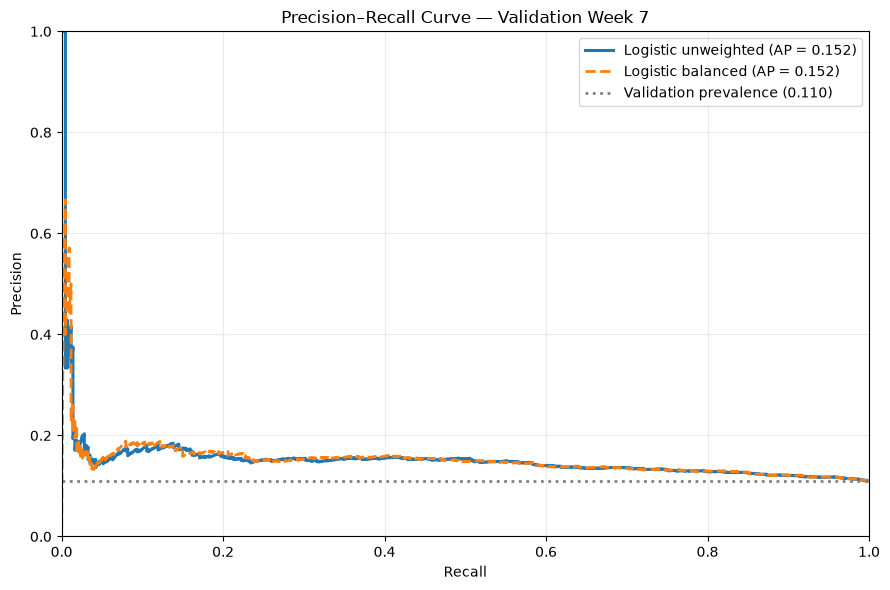

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve


# Compute validation precision-recall curves
unweighted_precision, unweighted_recall, _ = (
    precision_recall_curve(
        y_validation,
        logistic_validation_probability,
    )
)

balanced_precision, balanced_recall, _ = (
    precision_recall_curve(
        y_validation,
        logistic_balanced_validation_probability,
    )
)

unweighted_ap = logistic_baseline_results.loc[
    0,
    "average_precision",
]
balanced_ap = logistic_balanced_results.loc[
    0,
    "average_precision",
]

# Plot validation curves without selecting a threshold
fig, axis = plt.subplots(figsize=(9, 6))

axis.plot(
    unweighted_recall,
    unweighted_precision,
    linewidth=2.2,
    label=(
        "Logistic unweighted "
        f"(AP = {unweighted_ap:.3f})"
    ),
)

axis.plot(
    balanced_recall,
    balanced_precision,
    linewidth=2.0,
    linestyle="--",
    label=(
        "Logistic balanced "
        f"(AP = {balanced_ap:.3f})"
    ),
)

axis.axhline(
    validation_prevalence,
    color="gray",
    linestyle=":",
    linewidth=2,
    label=(
        "Validation prevalence "
        f"({validation_prevalence:.3f})"
    ),
)

axis.set(
    title="Precision–Recall Curve — Validation Week 7",
    xlabel="Recall",
    ylabel="Precision",
    xlim=(0, 1),
    ylim=(0, 1),
)

axis.grid(alpha=0.25)
axis.legend(loc="upper right")
fig.tight_layout()

plt.show()

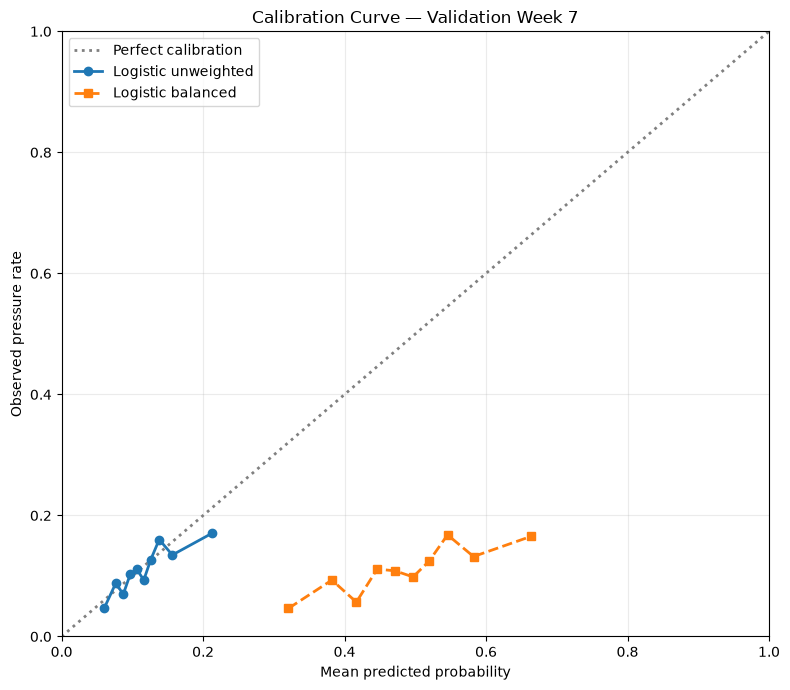

In [23]:
from sklearn.calibration import calibration_curve


# Estimate calibration using equal-frequency probability bins
unweighted_observed, unweighted_predicted = (
    calibration_curve(
        y_validation,
        logistic_validation_probability,
        n_bins=10,
        strategy="quantile",
    )
)

balanced_observed, balanced_predicted = (
    calibration_curve(
        y_validation,
        logistic_balanced_validation_probability,
        n_bins=10,
        strategy="quantile",
    )
)

fig, axis = plt.subplots(figsize=(8, 7))

axis.plot(
    [0, 1],
    [0, 1],
    color="gray",
    linestyle=":",
    linewidth=2,
    label="Perfect calibration",
)

axis.plot(
    unweighted_predicted,
    unweighted_observed,
    marker="o",
    linewidth=2,
    label="Logistic unweighted",
)

axis.plot(
    balanced_predicted,
    balanced_observed,
    marker="s",
    linestyle="--",
    linewidth=2,
    label="Logistic balanced",
)

axis.set(
    title="Calibration Curve — Validation Week 7",
    xlabel="Mean predicted probability",
    ylabel="Observed pressure rate",
    xlim=(0, 1),
    ylim=(0, 1),
)

axis.grid(alpha=0.25)
axis.legend(loc="upper left")
fig.tight_layout()

plt.show()

In [24]:
from joblib import dump


# Define Stage 6 output locations
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

STAGE_6_MODEL_PATH = (
    MODELS_DIR
    / "logistic_regression_stage6.joblib"
)
STAGE_6_RESULTS_PATH = (
    REPORTS_DIR
    / "stage6_baseline_model_results.csv"
)
STAGE_6_COEFFICIENTS_PATH = (
    REPORTS_DIR
    / "stage6_logistic_coefficients.csv"
)
STAGE_6_PREDICTIONS_PATH = (
    REPORTS_DIR
    / "stage6_validation_predictions.parquet"
)
STAGE_6_DECILES_PATH = (
    REPORTS_DIR
    / "stage6_validation_deciles.csv"
)

# Persist the selected fitted pipeline and validation evidence
dump(
    selected_stage_6_pipeline,
    STAGE_6_MODEL_PATH,
)

model_selection_table.to_csv(
    STAGE_6_RESULTS_PATH,
    index=False,
)

coefficient_table.sort_values(
    "absolute_coefficient",
    ascending=False,
).to_csv(
    STAGE_6_COEFFICIENTS_PATH,
    index=False,
)

validation_predictions.to_parquet(
    STAGE_6_PREDICTIONS_PATH,
    index=False,
)

validation_decile_summary.to_csv(
    STAGE_6_DECILES_PATH,
    index=False,
)

stage_6_artifacts = pd.DataFrame(
    [
        {
            "artifact": "selected_pipeline",
            "path": str(STAGE_6_MODEL_PATH),
        },
        {
            "artifact": "model_results",
            "path": str(STAGE_6_RESULTS_PATH),
        },
        {
            "artifact": "model_coefficients",
            "path": str(STAGE_6_COEFFICIENTS_PATH),
        },
        {
            "artifact": "validation_predictions",
            "path": str(STAGE_6_PREDICTIONS_PATH),
        },
        {
            "artifact": "validation_deciles",
            "path": str(STAGE_6_DECILES_PATH),
        },
    ]
)

stage_6_artifacts["exists"] = stage_6_artifacts[
    "path"
].map(lambda path: Path(path).is_file())

stage_6_artifacts["size_kib"] = stage_6_artifacts[
    "path"
].map(
    lambda path: Path(path).stat().st_size / 1_024
)

assert stage_6_artifacts["exists"].all()

display(
    stage_6_artifacts.style.format(
        {
            "size_kib": "{:,.2f}",
        }
    )
)

,artifact,path,exists,size_kib
0,selected_pipeline,C:\Users\yvett\OneDrive\Documentos\Francisco Fonseca\nfl-pressure-prediction\models\logistic_regression_stage6.joblib,True,9.22
1,model_results,C:\Users\yvett\OneDrive\Documentos\Francisco Fonseca\nfl-pressure-prediction\reports\stage6_baseline_model_results.csv,True,0.41
2,model_coefficients,C:\Users\yvett\OneDrive\Documentos\Francisco Fonseca\nfl-pressure-prediction\reports\stage6_logistic_coefficients.csv,True,11.10
3,validation_predictions,C:\Users\yvett\OneDrive\Documentos\Francisco Fonseca\nfl-pressure-prediction\reports\stage6_validation_predictions.parquet,True,92.71
4,validation_deciles,C:\Users\yvett\OneDrive\Documentos\Francisco Fonseca\nfl-pressure-prediction\reports\stage6_validation_deciles.csv,True,1.18


In [26]:
from joblib import load


# Reload every persisted Stage 6 artifact
reloaded_stage_6_pipeline = load(STAGE_6_MODEL_PATH)

reloaded_results = pd.read_csv(
    STAGE_6_RESULTS_PATH
)
reloaded_coefficients = pd.read_csv(
    STAGE_6_COEFFICIENTS_PATH
)
reloaded_predictions = pd.read_parquet(
    STAGE_6_PREDICTIONS_PATH
)
reloaded_deciles = pd.read_csv(
    STAGE_6_DECILES_PATH
)

# Reproduce validation probabilities from the serialized pipeline
reloaded_validation_probability = (
    reloaded_stage_6_pipeline.predict_proba(
        X_validation
    )[:, 1]
)

artifact_validation = pd.DataFrame(
    [
        {
            "check": "Reloaded pipeline reproduces probabilities",
            "observed": np.allclose(
                reloaded_validation_probability,
                logistic_validation_probability,
                rtol=0.0,
                atol=1e-15,
            ),
        },
        {
            "check": "Results contain three candidates",
            "observed": len(reloaded_results) == 3,
        },
        {
            "check": "Exactly one selected model",
            "observed": (
                reloaded_results[
                    "selected_stage_6_model"
                ].sum()
                == 1
            ),
        },
        {
            "check": "Coefficient count is complete",
            "observed": (
                len(reloaded_coefficients)
                == len(transformed_feature_names)
            ),
        },
        {
            "check": "Validation predictions contain all rows",
            "observed": len(reloaded_predictions) == 3_865,
        },
        {
            "check": "Validation positives are preserved",
            "observed": (
                reloaded_predictions[
                    "pressure_actual"
                ].sum()
                == 427
            ),
        },
        {
            "check": "Ten validation deciles are preserved",
            "observed": len(reloaded_deciles) == 10,
        },
    ]
)

artifact_validation["status"] = np.where(
    artifact_validation["observed"],
    "PASS",
    "FAIL",
)

assert artifact_validation["status"].eq("PASS").all()
print(artifact_validation)

                                        check  observed status
0  Reloaded pipeline reproduces probabilities      True   PASS
1            Results contain three candidates      True   PASS
2                  Exactly one selected model      True   PASS
3               Coefficient count is complete      True   PASS
4     Validation predictions contain all rows      True   PASS
5          Validation positives are preserved      True   PASS
6        Ten validation deciles are preserved      True   PASS


## Stage 6 conclusions

Stage 6 established a reproducible and leakage-safe baseline modeling workflow.

### Data boundaries

- Training used actual NFL weeks 1–6: 27,950 defender-play rows.
- Model comparison used validation week 7: 3,865 rows.
- Test week 8 remained untouched.
- No plays were shared between train, validation and test.
- The model used 50 numeric predictors and one categorical predictor.
- Identifiers, audit variables, the target and post-snap PFF outcomes were excluded.

### Baseline results

| Model | Average Precision | ROC-AUC | Log Loss |
|---|---:|---:|---:|
| DummyClassifier prior | 0.110479 | 0.500000 | 0.347754 |
| Logistic Regression unweighted | **0.151899** | 0.600006 | **0.342382** |
| Logistic Regression balanced | 0.151749 | **0.601697** | 0.675077 |

The unweighted logistic regression was selected because Average Precision was
the predefined primary metric. It also achieved the best Log Loss.

Compared with the trivial baseline, the selected model produced:

- An absolute AP improvement of 0.041420.
- A relative AP improvement of 37.49%.
- An absolute ROC-AUC improvement of 0.100006.
- A Log Loss reduction of 0.005372.

### Interpretation

The selected model demonstrates that snap-time spatial, movement and alignment
features contain predictive signal for pass-rush pressure. The signal is useful
but moderate: the top validation probability decile reached a 17.054% observed
pressure rate, equivalent to 1.544 times the overall validation prevalence.

The balanced model ranked cases similarly, but substantially overestimated
positive probabilities. Its class weighting increased predicted probabilities
into ranges far above the observed pressure rates, explaining its poor Log Loss.

Logistic coefficients represent conditional predictive associations, not causal
effects. Numeric coefficients correspond to one-standard-deviation changes after
scaling. One-hot position coefficients should be treated primarily as predictive
importance because no reference category was dropped.

### Selected Stage 6 pipeline

The selected pipeline is:

1. `StandardScaler` for numeric predictors.
2. `OneHotEncoder(handle_unknown="ignore")` for the rusher position.
3. Unweighted logistic regression with L2 regularization.

The fitted pipeline and its validation evidence were persisted successfully and
passed reload reproducibility checks.

No classification threshold was selected during Stage 6. Threshold selection
must use validation only after the final candidate model is chosen. Test week 8
must remain untouched until the final evaluation stage.

In [28]:
# Run the final Stage 6 quality gate
stage_6_quality_checks = [
    {
        "check_id": "M6-01",
        "check": "Approved temporal split preserved",
        "passed": (
            len(train_table) == 27_950
            and len(validation_table) == 3_865
            and len(test_table) == 4_444
        ),
    },
    {
        "check_id": "M6-02",
        "check": "No plays shared between splits",
        "passed": overlap_summary["shared_plays"].eq(0).all(),
    },
    {
        "check_id": "M6-03",
        "check": "Feature contract contains 51 predictors",
        "passed": (
            len(NUMERIC_FEATURES) == 50
            and len(CATEGORICAL_FEATURES) == 1
            and len(FEATURE_COLUMNS) == 51
        ),
    },
    {
        "check_id": "M6-04",
        "check": "Forbidden variables excluded",
        "passed": (
            set(X_train.columns).isdisjoint(
                FORBIDDEN_FEATURE_COLUMNS
            )
            and set(X_validation.columns).isdisjoint(
                FORBIDDEN_FEATURE_COLUMNS
            )
        ),
    },
    {
        "check_id": "M6-05",
        "check": "Training and validation matrices complete",
        "passed": (
            X_train.isna().sum().sum() == 0
            and X_validation.isna().sum().sum() == 0
        ),
    },
    {
        "check_id": "M6-06",
        "check": "Selected model improves validation AP",
        "passed": (
            logistic_metrics["average_precision"]
            > dummy_metrics["average_precision"]
        ),
    },
    {
        "check_id": "M6-07",
        "check": "Unweighted logistic pipeline selected",
        "passed": (
            selected_stage_6_model_name
            == "LogisticRegression_unweighted"
        ),
    },
    {
        "check_id": "M6-08",
        "check": "Serialized pipeline reproduces probabilities",
        "passed": np.allclose(
            reloaded_validation_probability,
            logistic_validation_probability,
            rtol=0.0,
            atol=1e-15,
        ),
    },
    {
        "check_id": "M6-09",
        "check": "Test matrices were not created",
        "passed": (
            "X_test" not in globals()
            and "y_test" not in globals()
        ),
    },
    {
        "check_id": "M6-10",
        "check": "All Stage 6 artifacts exist",
        "passed": stage_6_artifacts["exists"].all(),
    },
]

stage_6_quality_report = pd.DataFrame(
    stage_6_quality_checks
)

stage_6_quality_report["status"] = np.where(
    stage_6_quality_report["passed"],
    "PASS",
    "FAIL",
)

STAGE_6_QUALITY_REPORT_PATH = (
    REPORTS_DIR
    / "stage6_quality_report.csv"
)

stage_6_quality_report.to_csv(
    STAGE_6_QUALITY_REPORT_PATH,
    index=False,
)

assert stage_6_quality_report["status"].eq("PASS").all()
assert STAGE_6_QUALITY_REPORT_PATH.is_file()

print(stage_6_quality_report)

  check_id                                         check  passed status
0    M6-01             Approved temporal split preserved    True   PASS
1    M6-02                No plays shared between splits    True   PASS
2    M6-03       Feature contract contains 51 predictors    True   PASS
3    M6-04                  Forbidden variables excluded    True   PASS
4    M6-05     Training and validation matrices complete    True   PASS
5    M6-06         Selected model improves validation AP    True   PASS
6    M6-07         Unweighted logistic pipeline selected    True   PASS
7    M6-08  Serialized pipeline reproduces probabilities    True   PASS
8    M6-09                Test matrices were not created    True   PASS
9    M6-10                   All Stage 6 artifacts exist    True   PASS
